In [1]:
# From my Exploratory Data Analysis Notebook:


# As for the criteria that I am using to decide what features should be in the model,
# Refer to the criteria below:

""" For numerical features you want:

High correlation with ClosePrice, above 0.1 at minimum, ideally above 0.2. Below that it's adding noise more than signal
Low null percentage, above 30% null is risky for model
Low multicollinearity with other features especially for linear regression
Makes intuitive sense, must explain why a feature would affect price, as correlation can be coincidental

For categorical features you want:

Low unique values, keeps your feature matrix manageable after one-hot encoding
High price variance across categories, means the category actually separates expensive from cheap
Low null percentage, above 30% null is risky for model

These matter because:
Low unique + low variance = clean but useless
High variance + high unique = useful signal but blows up your matrix
Low unique + high variance + 80% null = you'd lose most of your data imputing or dropping

"""

" For numerical features you want:\n\nHigh correlation with ClosePrice, above 0.1 at minimum, ideally above 0.2. Below that it's adding noise more than signal\nLow null percentage, above 30% null is risky for model\nLow multicollinearity with other features especially for linear regression\nMakes intuitive sense, must explain why a feature would affect price, as correlation can be coincidental\n\nFor categorical features you want:\n\nLow unique values, keeps your feature matrix manageable after one-hot encoding\nHigh price variance across categories, means the category actually separates expensive from cheap\nLow null percentage, above 30% null is risky for model\n\nThese matter because:\nLow unique + low variance = clean but useless\nHigh variance + high unique = useful signal but blows up your matrix\nLow unique + high variance + 80% null = you'd lose most of your data imputing or dropping\n\n"

In [2]:
import numpy as np
import pandas as pd
import glob

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


files = glob.glob('/home/jorge/Documents/IDX/datasets/*.csv')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

rows_before_type_filter = len(df)
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

rows_removed = rows_before_type_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_type_filter:.1%}) that were not Residential/SingleFamilyResidence")

print(f"There are {df.shape[0]} rows and {df.shape[1]} columns after filtering data for Residential and SingleFamilyResidence.")

(141997, 78)
Removed 139,826 rows (49.6%) that were not Residential/SingleFamilyResidence
There are 141997 rows and 78 columns after filtering data for Residential and SingleFamilyResidence.


In [3]:
# Making sure to filter for the features that we are interested in, not the final list of features
# And then check how many are null in each column of interest

cols_of_interest = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                    'LotSizeSquareFeet', 'YearBuilt', 'CloseDate', 'Latitude', 'Longitude',
                   'City', 'MLSAreaMajor', 'CountyOrParish', 'AssociationFee', 'Stories',
                   'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']

print("Number of Null Rows in each column of interest \n")
print(df[cols_of_interest].isnull().sum())

Number of Null Rows in each column of interest 

ClosePrice                   0
LivingArea                  78
BedroomsTotal                0
BathroomsTotalInteger       13
LotSizeSquareFeet         2433
YearBuilt                   97
CloseDate                    0
Latitude                    13
Longitude                   13
City                        49
MLSAreaMajor             20811
CountyOrParish               0
AssociationFee           41364
Stories                  14774
FireplaceYN                108
NewConstructionYN        10830
AttachedGarageYN         17195
ViewYN                   12901
PoolPrivateYN            10978
dtype: int64


In [4]:
# Chose to drop rows with missing LivingArea, Bathrooms, Latitude, Longitude because
# 1. Living Area and Square Footage vary most by location, and has a relatively low number of missing values,
# making imputing this data not worthwhile
# 2. Bathrooms also has relatively low number of missing values
# 3. Latitude and Longitude are needed for Geographical features, also have relatively low number of missing values


rows_before_dropna = len(df)
df = df.dropna(subset=['LivingArea', 'BathroomsTotalInteger', 'Latitude', 'Longitude', 'LotSizeSquareFeet'])


# Chose to impute null YearBuilt values with median because as shown on histogram below, they tend to fall
# within the range of 1950 - 1975, peaking at around 1960

# LEAKAGE FIX: compute the median from train rows only (CloseDate < 2026-05-01) instead of
# the full df, so the test set's YearBuilt/Stories values never influence the imputed value
train_mask = pd.to_datetime(df['CloseDate']) < '2026-05-01'

yearbuilt_median = df.loc[train_mask, 'YearBuilt'].median()
print(yearbuilt_median)

df['YearBuilt'] = df['YearBuilt'].fillna(yearbuilt_median)

# Chose to impute AssociationFee with 0, since no data assumes no Association Fee
df['AssociationFee'] = df['AssociationFee'].fillna(0)

# Impute Stories with median, since empty doesn't imply no stories
stories_median = df.loc[train_mask, 'Stories'].median()
df['Stories'] = df['Stories'].fillna(stories_median)

# Impute boolean features with False - absence of data assumes feature not present
for col in ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN']:
    df[col] = df[col].fillna(False)

1976.0


In [5]:
print("After cleaning:")
print(df[cols_of_interest].isnull().sum())
print(df.shape)

rows_removed = rows_before_dropna - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_dropna:.1%}) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize")

After cleaning:
ClosePrice                   0
LivingArea                   0
BedroomsTotal                0
BathroomsTotalInteger        0
LotSizeSquareFeet            0
YearBuilt                    0
CloseDate                    0
Latitude                     0
Longitude                    0
City                        44
MLSAreaMajor             20740
CountyOrParish               0
AssociationFee               0
Stories                      0
FireplaceYN                  0
NewConstructionYN            0
AttachedGarageYN             0
ViewYN                       0
PoolPrivateYN                0
dtype: int64
(139461, 78)
Removed 2,536 rows (1.8%) with missing LivingArea/Bathrooms/Latitude/Longitude/LotSize


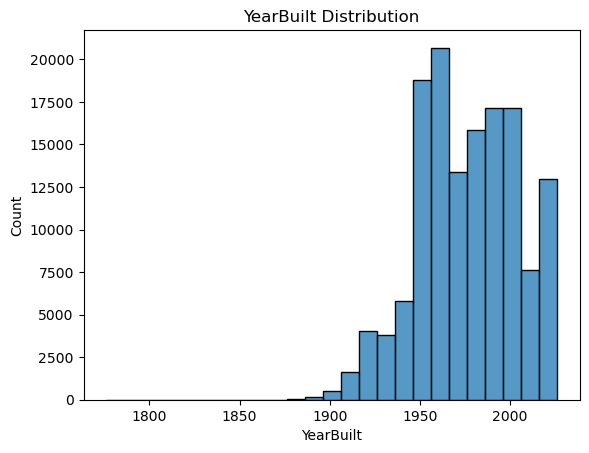

In [6]:
# Histogram in question to show how homes generally fall within said range of 1950-1970

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['YearBuilt'].dropna(), bins=25)
plt.title('YearBuilt Distribution')
plt.show()

In [7]:
# Before moving on, I want to remove the clear extreme outlier in the Glennville Area, $900m home
# This is to prevent issues further on when using the model,
# since the difference in medians between the first 2 MLSAreas is $880m
# Median prices in Malibu, the 2nd highest in the MLSAreas behind Glennville, is $12m,
# To still retain legitimate data, I will limit analysis to homes with prices over 50k and under $15m

# BEST PRACTICE FIX: outlier thresholds must be learned from training data alone. Compute the
# 0.5th/99.5th percentile of ClosePrice using train rows only, then apply those frozen cutoffs
# to the whole dataset (both train and test) - never recompute percentiles on test data.
train_mask = pd.to_datetime(df['CloseDate']) < '2026-05-01'

closeprice_low = df.loc[train_mask, 'ClosePrice'].quantile(0.005)
closeprice_high = df.loc[train_mask, 'ClosePrice'].quantile(0.995)
print(f"Train-only ClosePrice bounds: ${closeprice_low:,.0f} - ${closeprice_high:,.0f}")

rows_before_price_filter = len(df)
df = df[(df['ClosePrice'] >= closeprice_low) & (df['ClosePrice'] <= closeprice_high)]

rows_removed = rows_before_price_filter - len(df)
print(f"Removed {rows_removed:,} rows ({rows_removed / rows_before_price_filter:.1%}) outside the train-only ClosePrice bounds")

Train-only ClosePrice bounds: $185,000 - $8,915,100
Removed 1,359 rows (1.0%) outside the train-only ClosePrice bounds


In [8]:
# Setting test/train splits for the model


df['CloseDate'] = pd.to_datetime(df['CloseDate'])

test = df[df['CloseDate'] >= '2026-05-01']
train = df[df['CloseDate'] < '2026-05-01']

print(train.shape)
print(test.shape)

(126399, 78)
(11703, 78)


In [9]:
# Deciding what categorical features should be encoded, by checking what causes price to vary
# City would be a clear one to check, since homes are more expensive in different cities

print(df.groupby('City')['ClosePrice'].median().sort_values(ascending=False).head(20))

City
Newport Coast      5550000.0
Montecito          5400000.0
Hillsborough       5280000.0
Atherton           5200000.0
Hidden Hills       5150000.0
Los Altos Hills    4965000.0
Corona Del Mar     4900000.0
Los Altos          4690000.0
Rancho Santa Fe    4600000.0
Monte Sereno       4202500.0
Saratoga           4150000.0
Bel Air            4124975.0
Portola Valley     4100000.0
Newport Beach      3995000.0
Carnelian Bay      3950000.0
Summerland         3900000.0
Malibu             3750000.0
Silverado          3750000.0
Rolling Hills      3730000.0
Sunset Beach       3675000.0
Name: ClosePrice, dtype: float64


In [10]:
# Additionally checking MLSAreaMajor

print(df.groupby('MLSAreaMajor')['ClosePrice'].median().sort_values(ascending=False).head(20))

MLSAreaMajor
CR - Crystal Cove                         7100000.0
SH - Shady Canyon                         6900000.0
144 - Manhattan Bch Hill                  6175000.0
N9 - Lower Newport Bay - Balboa Island    5850000.0
MCTO - Montecito                          5575000.0
N26 - Newport Coast                       5521000.0
HHIL - Hidden Hills                       5150000.0
CS - Corona Del Mar - Spyglass            5000000.0
C32 - Malibu Beach                        5000000.0
92067 - Rancho Santa Fe                   4635000.0
NP - Balboa Peninsula                     4500000.0
TRG - Turtle Ridge                        4490000.0
N8 - West Newport - Lido                  4400000.0
C01 - Beverly Hills                       4150000.0
204 - Murrieta-Hills West                 4000000.0
NL - North Laguna                         3982688.0
SMLD - Summerland                         3900000.0
N7 - West Bay - Santa Ana Heights         3847500.0
NV - East Bluff - Harbor View             3838000.0

In [11]:
# Additionally checking County or Parish

print(df.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(20))

CountyOrParish
San Mateo          2050000.0
Mono               1910000.0
Santa Clara        1900000.0
Orange             1400000.0
Santa Cruz         1350000.0
San Francisco      1335000.0
Alameda            1300000.0
Marin              1287500.0
San Diego          1059000.0
Los Angeles        1008000.0
Ventura             970000.0
Monterey            958000.0
San Luis Obispo     935000.0
Contra Costa        899000.0
Napa                880000.0
Sonoma              790000.0
San Benito          780000.0
Santa Barbara       759000.0
El Dorado           725000.0
Placer              668750.0
Name: ClosePrice, dtype: float64


In [12]:
print(df['City'].nunique())
print(df['CountyOrParish'].nunique())
print(df['MLSAreaMajor'].nunique())

989
60
1019


In [13]:
# City has 1007 unique values, MLSAreaMajor has 1027,
# Too many for one-hot encoding. CountyOrParish has 60 which is more manageable,
# hence why I chose it over the other location metrics

numerical_features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 
                      'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude',
                      'AssociationFee', 'Stories']

boolean_features = ['FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 
                    'ViewYN', 'PoolPrivateYN']

categorical_features = ['CountyOrParish']
target = 'ClosePrice'

features = numerical_features + boolean_features + categorical_features


In [14]:
# Here, I am doing some additional checking for extreme outliers to filter out,
# Brought to my attention by my groupmates in DS55

numeric_cols = numerical_features
print(df[numeric_cols].describe())

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  138102.000000  138102.000000          138102.000000       1.381020e+05   
mean     2029.306374       3.489189               2.614618       3.735806e+05   
std       948.084337       0.948090               1.074691       1.753918e+07   
min         0.000000       0.000000               0.000000       0.000000e+00   
25%      1389.000000       3.000000               2.000000       5.663000e+03   
50%      1819.000000       3.000000               2.000000       7.265000e+03   
75%      2434.000000       4.000000               3.000000       1.042500e+04   
max     17153.000000      22.000000              35.000000       1.938943e+09   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  138102.000000  138102.000000  138102.000000   138102.000000   
mean     1975.773218      34.760488    -118.625262       72.771528   
std        27.572231       1.751073       3.225167      267.

In [15]:
# Latitude and Longitude bounds for California (inspired by Kelvin)
df = df[
    (df['Latitude'] >= 32.5) & (df['Latitude'] <= 42.5) &
    (df['Longitude'] >= -124.5) & (df['Longitude'] <= -114.5)
]

# LivingArea must be positive non-zero number to be seriously considered
df = df[df['LivingArea'] > 0]

# Reasonable caps for both bedrooms and bathrooms, captures legit values while removing extreme outliers
df = df[(df['BedroomsTotal'] <= 15) & (df['BathroomsTotalInteger'] <= 15)]

# LotSize cap of 10 acres = 435,600 sqft, reasonable bound accounts for large lots and filters bad data
df = df[df['LotSizeSquareFeet'] <= 435600]

# LEAKAGE FIX: the block above only ever reassigns `df`, but `train`/`test` were already sliced
# off as separate DataFrames earlier (test/train split cell), so these bounds never actually
# reached the modeling data. Applying the same fixed bounds directly to train/test here so the
# outliers are actually removed from what the model trains/evaluates on.
train_before = len(train)
test_before = len(test)

train = train[
    (train['Latitude'] >= 32.5) & (train['Latitude'] <= 42.5) &
    (train['Longitude'] >= -124.5) & (train['Longitude'] <= -114.5)
]
test = test[
    (test['Latitude'] >= 32.5) & (test['Latitude'] <= 42.5) &
    (test['Longitude'] >= -124.5) & (test['Longitude'] <= -114.5)
]

train = train[train['LivingArea'] > 0]
test = test[test['LivingArea'] > 0]

train = train[(train['BedroomsTotal'] <= 15) & (train['BathroomsTotalInteger'] <= 15)]
test = test[(test['BedroomsTotal'] <= 15) & (test['BathroomsTotalInteger'] <= 15)]

train = train[train['LotSizeSquareFeet'] <= 435600]
test = test[test['LotSizeSquareFeet'] <= 435600]

print(train.shape)
print(test.shape)

train_removed = train_before - len(train)
test_removed = test_before - len(test)
print(f"Removed {train_removed:,} train rows ({train_removed / train_before:.1%}) and {test_removed:,} test rows ({test_removed / test_before:.1%}) as lat/long/size outliers")

(125549, 78)
(11631, 78)
Removed 850 train rows (0.7%) and 72 test rows (0.6%) as lat/long/size outliers


In [16]:
# After fully filtering for bad values, we have around 139000 points of data to analyse

print(df[numerical_features + ['ClosePrice']].describe())


# After filtering, 97% of rows remain, good retention

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet  \
count  137180.000000  137180.000000          137180.000000      137180.000000   
mean     2026.275506       3.488781               2.611175       14801.918150   
std       940.119139       0.941404               1.061523       33578.007549   
min       100.000000       0.000000               0.000000           0.000000   
25%      1388.000000       3.000000               2.000000        5663.000000   
50%      1817.000000       3.000000               2.000000        7242.000000   
75%      2431.000000       4.000000               3.000000       10265.250000   
max     17153.000000      15.000000              15.000000      435600.000000   

           YearBuilt       Latitude      Longitude  AssociationFee  \
count  137180.000000  137180.000000  137180.000000   137180.000000   
mean     1975.715053      34.760149    -118.660071       72.468595   
std        27.571574       1.686036       1.844744      265.

In [17]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [18]:
# Get cleaned data and preprocess it, by encoding categorical features and scaling numerical values

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features + boolean_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(125549, 73)
(11631, 73)


In [19]:
df.to_csv('/home/jorge/Documents/IDX/datasets/cleaned/cleaned_data.csv', index=False)

print(f"Training set: {X_train_processed.shape}")
print(f"Test set: {X_test_processed.shape}")
print(f"Features used: {features}")
print("Cleaned CSV has been exported")

Training set: (125549, 73)
Test set: (11631, 73)
Features used: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude', 'AssociationFee', 'Stories', 'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN', 'ViewYN', 'PoolPrivateYN', 'CountyOrParish']
Cleaned CSV has been exported
